In [3]:
import os
import sys
import gzip
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format="retina"
%matplotlib inline

In [4]:
def apk(actual, predicted, k=15):
    if actual is None:
        return 1.0
    predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k)

def mapk(actual_dict, pred_dict, k=15):
    return sum(apk(actual_dict[u], pred_dict[u], k) for u in actual_dict) / len(actual_dict)

def recall_at_k(actual, predicted, k=15):
    predicted = predicted[:k]
    if actual is None:
        return 1.0
    return len(set(predicted) & set(actual)) / len(actual)

def precision_at_k(actual, predicted, k=15):
    predicted = predicted[:k]
    if predicted is None:
        return 1.0
    return len(set(predicted) & set(actual)) / k

def ndcg_at_k(actual, predicted, k=15):
    predicted = predicted[:k]
    dcg = 0.0
    for i, p in enumerate(predicted):
        if p in actual:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / idcg

def compute_metrics(test, preds, k=15):
    recalls = []
    precisions = []
    ndcgs = []
    for u in tqdm(test, desc="Iterating over test"):
        recalls.append(recall_at_k(test[u], preds.get(u, []), k))
        precisions.append(precision_at_k(test[u], preds.get(u, []), k))
        ndcgs.append(ndcg_at_k(test[u], preds.get(u, []), k))

    return {
        f"MAP@{k}": mapk(test, preds, k),
        f"Recall@{k}": sum(recalls) / len(recalls),
        f"Precision@{k}": sum(precisions) / len(precisions),
        f"NDCG@{k}": sum(ndcgs) / len(ndcgs)
    }

In [5]:
test_path = "/home/datalab/nfs/deepfm/data/train_21/test_dict.pkl.gz"
preds_path = "/home/datalab/nfs/deepfm/data/train_21/recommendations/kts_for_dts.pkl.gz"

with gzip.open(test_path, "rb") as f:
    test = pickle.load(f)

with gzip.open(preds_path, "rb") as f:
    preds = pickle.load(f)

На самых популярных 3500

In [32]:
top_users = sorted(test.items(), key=lambda x: len(x[1]), reverse=True)[:3500]
top_users = dict(top_users)

compute_metrics(top_users, preds, k=10)

Iterating over test: 100%|██████████| 3500/3500 [00:00<00:00, 11158.12it/s]


{'MAP@10': 0.0917651473922903,
 'Recall@10': 0.024523118119404084,
 'Precision@10': 0.15831428571428788,
 'NDCG@10': 0.17405441252020648}

Смотрим на recall@100

In [7]:
compute_metrics(test, preds, k=100)

Iterating over test: 100%|██████████| 118998/118998 [00:52<00:00, 2265.47it/s]


{'MAP@100': 0.06380055436928381,
 'Recall@100': 0.25572529080121376,
 'Precision@100': 0.04367644834370779,
 'NDCG@100': 0.18904675873234197}

Смотрим на Precision и MAP. Это результаты модели, которая училась на 6 месяцах данных. Довольно печально :(

In [10]:
lens = np.array([len(v) for _, v in test.items()])

np.median(lens), np.mean(lens)

(16.0, 19.42001546244475)

In [16]:
compute_metrics(test, preds, k=10)

Iterating over test: 100%|██████████| 118998/118998 [00:08<00:00, 13847.85it/s]


{'MAP@10': 0.05547100875164204,
 'Recall@10': 0.06392539353664606,
 'Precision@10': 0.10320341518350977,
 'NDCG@10': 0.11857839930873752}

Результаты модели которая училась на 2 месяцах и тестировалась примерно на неделе

In [20]:
compute_metrics(test, preds, k=10)

Iterating over test: 100%|██████████| 5640/5640 [00:02<00:00, 2455.05it/s]


{'MAP@10': 0.029122453000112535,
 'Recall@10': 0.031663637898289056,
 'Precision@10': 0.08898936170212887,
 'NDCG@10': 0.07023546757084675}

In [33]:
k_vals = list(range(2, 21))
maps = []
recalls = []
precisions = []
ndcgs = []

for k in k_vals:
    metrics = compute_metrics(top_users, preds, k)
    maps.append(metrics[f"MAP@{k}"])
    recalls.append(metrics[f"Recall@{k}"])
    precisions.append(metrics[f"Precision@{k}"])
    ndcgs.append(metrics[f"NDCG@{k}"])

Iterating over test:   0%|          | 0/3500 [00:00<?, ?it/s]

Iterating over test: 100%|██████████| 3500/3500 [00:00<00:00, 6587.78it/s]


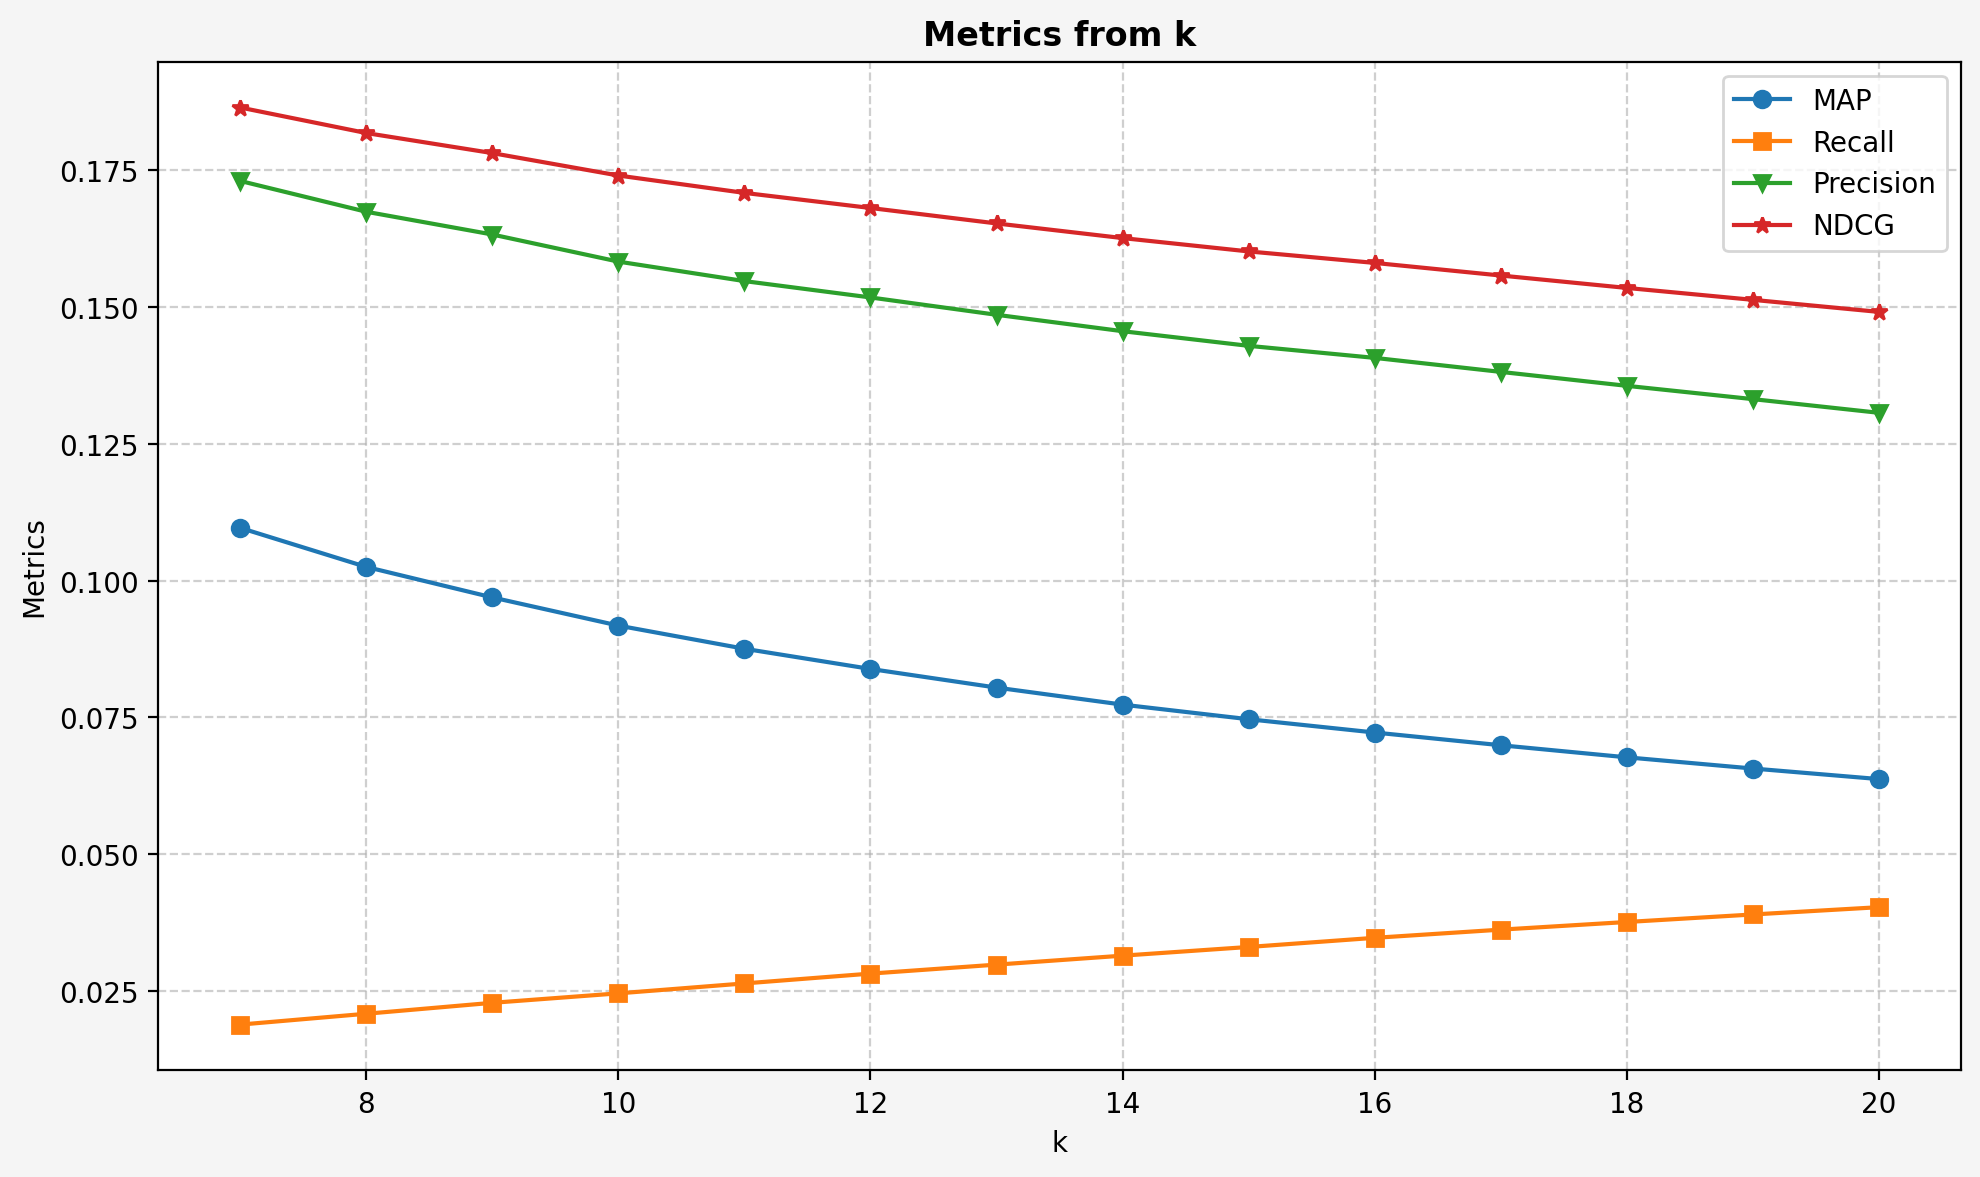

In [34]:
fig = plt.figure(figsize=(10, 6), facecolor="whitesmoke")

m = 5

plt.plot(k_vals[m:], maps[m:], label="MAP", marker="o")
plt.plot(k_vals[m:], recalls[m:], label="Recall", marker="s")
plt.plot(k_vals[m:], precisions[m:], label="Precision", marker="v")
plt.plot(k_vals[m:], ndcgs[m:], label="NDCG", marker="*")

plt.xlabel("k")
plt.ylabel("Metrics")
plt.title("Metrics from k", weight="bold")

plt.legend()
plt.grid(alpha=0.6, linestyle="--")
plt.tight_layout()
plt.show()

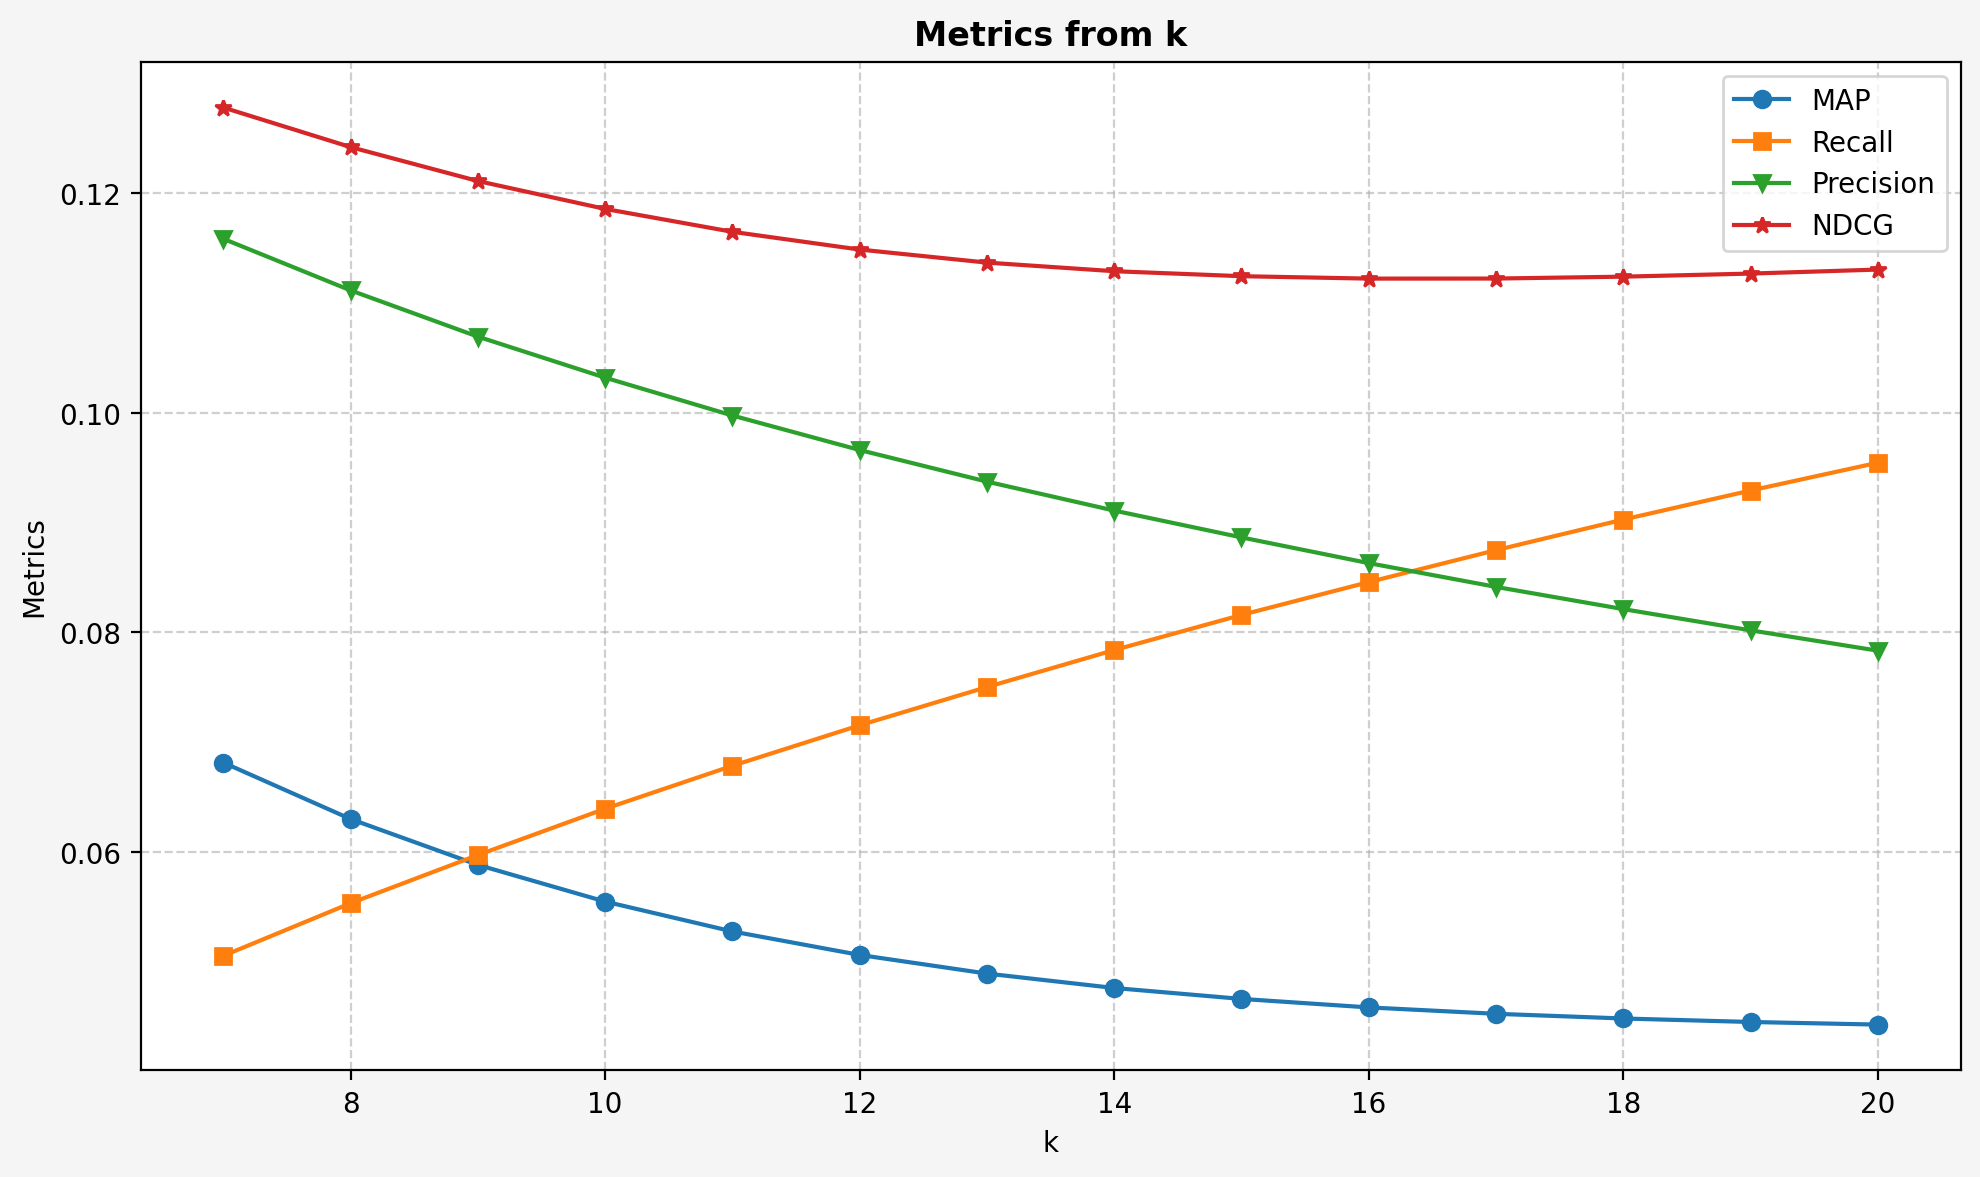

In [28]:
fig = plt.figure(figsize=(10, 6), facecolor="whitesmoke")

m = 5

plt.plot(k_vals[m:], maps[m:], label="MAP", marker="o")
plt.plot(k_vals[m:], recalls[m:], label="Recall", marker="s")
plt.plot(k_vals[m:], precisions[m:], label="Precision", marker="v")
plt.plot(k_vals[m:], ndcgs[m:], label="NDCG", marker="*")

plt.xlabel("k")
plt.ylabel("Metrics")
plt.title("Metrics from k", weight="bold")

plt.legend()
plt.grid(alpha=0.6, linestyle="--")
plt.tight_layout()
plt.show()

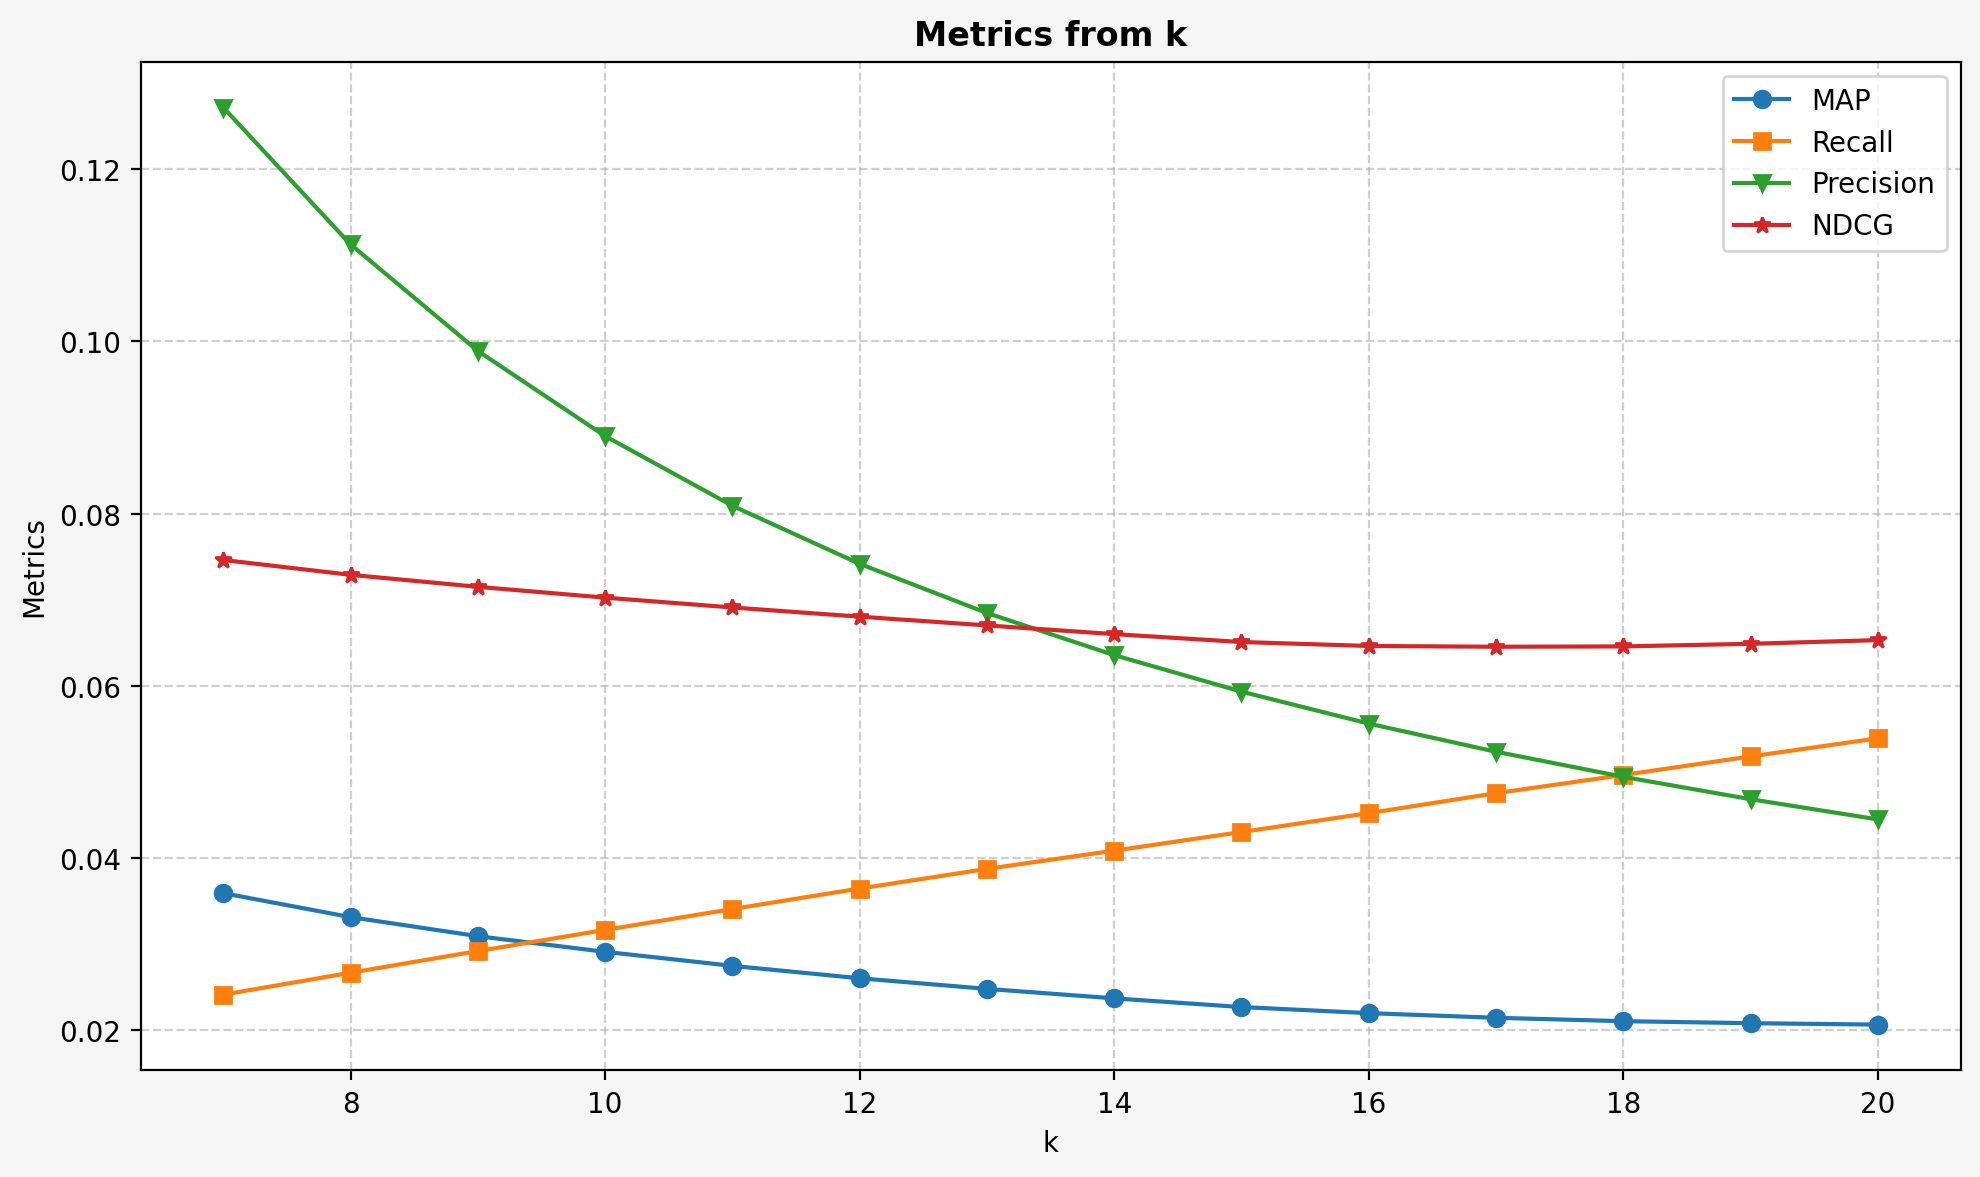

In [24]:
fig = plt.figure(figsize=(10, 6), facecolor="whitesmoke")

m = 5

plt.plot(k_vals[m:], maps[m:], label="MAP", marker="o")
plt.plot(k_vals[m:], recalls[m:], label="Recall", marker="s")
plt.plot(k_vals[m:], precisions[m:], label="Precision", marker="v")
plt.plot(k_vals[m:], ndcgs[m:], label="NDCG", marker="*")

plt.xlabel("k")
plt.ylabel("Metrics")
plt.title("Metrics from k", weight="bold")

plt.legend()
plt.grid(alpha=0.6, linestyle="--")
plt.tight_layout()
plt.show()